In [1]:
import jax
import jax.random as jr
import jax.numpy as jnp

import sys
sys.path.insert(0, "..")

from bayesoptax.loop import run, run_seeds
from bayesoptax.utils import Bounds

First, define an objective function. To test optimization, the Ackley function is defined below.

In [2]:
def ackley(x: jax.Array) -> jax.Array:
    sum1 = jnp.mean(x ** 2)
    sum2 = jnp.mean(jnp.cos(2 * jnp.pi * x))
    val = -20 * jnp.exp(-0.2 * jnp.sqrt(sum1)) - jnp.exp(sum2) + 20 + jnp.e
    return val

Determine the dimensionality and set the bounds for BO.
There are two ways to work with Bounds objects:
1. Uniform bounds e.g.:
`bounds = Bounds.uniform(-2., 2., D=1)`
2. Mixed bounds e.g.:
`bounds = Bounds(lb=[-2., -0.5], ub=[2., 3.])`

Then, there are two ways to run BO. 
1. A single BO loop using `run()`, which requires the objective function and the bounds. By default uses 10 initial points, 50 iterations, RBF kernel, and EI acquisition function, which can also all be passed into the function.
2. Multiple seeded BO loops using `run_seeds()`, which works similar to `run()` but also takes number of seeds.

In [ ]:
D = 6
bounds = Bounds.uniform(-32.768, 32.768, D=D)

results = run_seeds(
    objective=ackley,
    bounds=bounds,
    n_seeds=10,
    n_init=5*D,
    n_iter=100,
    kernel_name="matern52",
    acquisition_name="ts",
)

The resulting variable is a `BOResult` (or `MultiBOResult`) dataclass object which has a `.plot()` method. This plots the best-so-far objective against iteration. In the multi-seeded version, it plots the individual curves in low opacity with a mean curve and 95% confidence interval bands, as seen below.

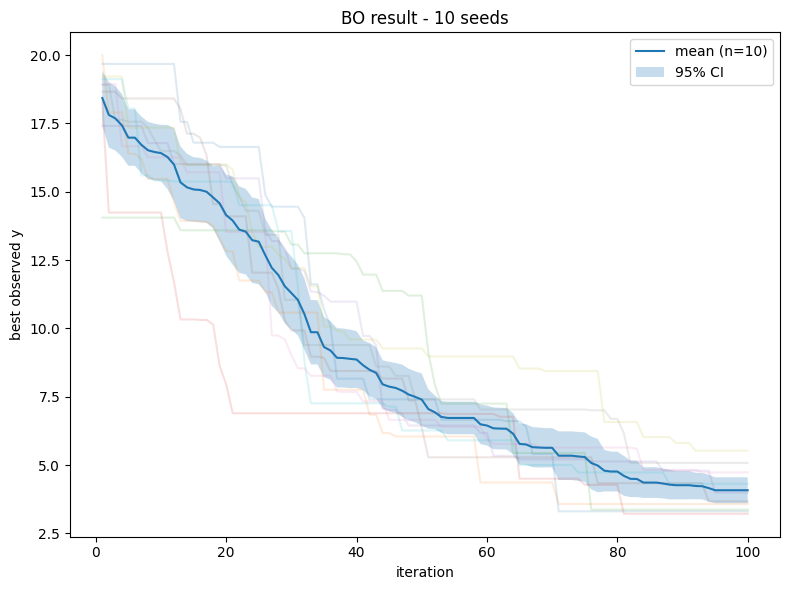

In [4]:
results.plot()